# 03 — Single-request performance (online, C = 1)

**Objective.** Measure how each server handles one request at a time, the regime of an interactive single user.

**Research question.** With exactly one request in flight, which backend gives the lower time to first token
(TTFT), the lower time per output token (TPOT) and the higher throughput?

**Data.** `online_points` at C = 1, campaign `online/main`, all five workload shapes (8B) and three shapes (1B).
Each point is the mean of 3 repetitions; latencies are per-repetition medians averaged over repetitions.

**Method.** Same client, same token-id prompts, fixed output length (`ignore_eos`), fresh server per point.
Direct backend comparisons use the BF16 pair; llama.cpp INT8 is shown for context only.

In [1]:
import pandas as pd
from IPython.display import display

from llm_backend_analysis.analysis import comparisons, memory, metrics
from llm_backend_analysis.data import loaders, registry
from llm_backend_analysis.reporting import Claim, claims_table, num, pct, rng, show, table, x
from llm_backend_analysis.visualization import plots, theme
from llm_backend_analysis.visualization.export import export_figure

theme.setup_notebook()
NOTEBOOK = "03_single_request_performance.ipynb"
MODEL = registry.primary_model()  # Llama-3.1-8B-Instruct; the 1B model is the cross-check

In [2]:
pts = loaders.online_points()
c1 = pts[pts["concurrency"] == 1].copy()
view = c1[c1["model"] == MODEL]
display(table(view[["workload_shape", "configuration_label", "output_tok_s_mean", "ttft_s_p50_mean", "tpot_s_p50_mean",
                    "e2e_s_p50_mean"]]
              .assign(tpot_s_p50_mean=view["tpot_s_p50_mean"] * 1e3)
              .rename(columns={"workload_shape": "Workload", "configuration_label": "Configuration",
                               "output_tok_s_mean": "Output tok/s", "ttft_s_p50_mean": "TTFT p50 (s)",
                               "tpot_s_p50_mean": "TPOT p50 (ms)", "e2e_s_p50_mean": "E2E p50 (s)"}),
              {"Output tok/s": "{:.1f}", "TTFT p50 (s)": "{:.2f}", "TPOT p50 (ms)": "{:.1f}", "E2E p50 (s)": "{:.1f}"},
              caption=f"{registry.model_label(MODEL)}, one request in flight"))

Workload,Configuration,Output tok/s,TTFT p50 (s),TPOT p50 (ms),E2E p50 (s)
128→512,vLLM · BF16,18.5,0.14,53.9,27.7
128→512,llama.cpp · BF16,21.6,0.59,45.3,23.7
128→512,llama.cpp · INT8 (Q8_0),30.2,0.45,32.3,17.0
512→512,vLLM · BF16,18.7,0.42,52.8,27.4
512→512,llama.cpp · BF16,21.0,2.34,43.2,24.4
512→512,llama.cpp · INT8 (Q8_0),28.7,1.54,31.9,17.8
4096→128,vLLM · BF16,12.8,3.19,53.4,10.0
4096→128,llama.cpp · BF16,4.6,21.03,54.0,27.9
4096→128,llama.cpp · INT8 (Q8_0),7.7,12.22,35.3,16.7
8192→256,vLLM · BF16,12.2,6.41,56.9,20.9


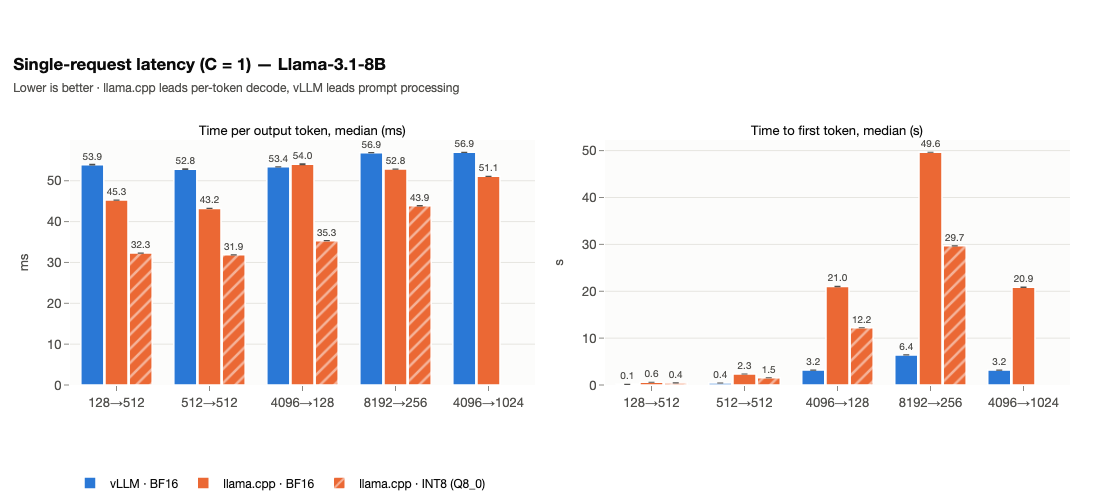

In [3]:
long = pd.concat([
    view.assign(metric="tpot", value=view["tpot_s_p50_mean"] * 1e3, spread=view["tpot_s_p50_std"] * 1e3),
    view.assign(metric="ttft", value=view["ttft_s_p50_mean"], spread=view["ttft_s_p50_std"]),
])
fig = plots.grouped_bars(long, x="workload_shape", y="value", error="spread", facet="metric",
                         facet_labels={"tpot": "Time per output token, median (ms)", "ttft": "Time to first token, median (s)"},
                         y_title=["ms", "s"], value_fmt=".1f",
                         title=f"Single-request latency (C = 1) — {registry.model_label(MODEL)}",
                         subtitle="Lower is better · llama.cpp leads per-token decode, vLLM leads prompt processing")
fig.show()
export_figure(fig, "single_request_latency", source=NOTEBOOK,
              caption="Median TPOT and TTFT with one request in flight, per workload and configuration (8B).")

In [4]:
r_tpot = comparisons.backend_ratio(c1, "tpot_s_p50_mean", precision="bf16")
r_ttft = comparisons.backend_ratio(c1, "ttft_s_p50_mean", precision="bf16")
r_out = comparisons.backend_ratio(c1, "output_tok_s_mean", precision="bf16")
decode_dom = c1[c1["osl"] >= c1["isl"]]["workload"].unique()
t8 = r_tpot[(r_tpot["model"] == MODEL)].set_index("workload")
o8 = r_out[(r_out["model"] == MODEL)].set_index("workload")
show(f"**BF16 pair, {registry.model_label(MODEL)}.** vLLM ÷ llama.cpp median TPOT per shape: "
     + ", ".join(f"{registry.workload_label(w, short=True)} {x(t8.loc[w, 'ratio'], 2)}" for w in t8.index)
     + f" (> 1 means llama.cpp is faster per token). vLLM's TTFT is {rng(1 / r_ttft[r_ttft['model'] == MODEL]['ratio'], x)} lower. "
     f"Net output throughput at C=1: llama.cpp leads on the decode-dominated shapes "
     f"({', '.join(registry.workload_label(w, short=True) for w in o8.index if o8.loc[w, 'ratio'] < 1)}: "
     f"vLLM ÷ llama.cpp {rng(o8[o8['ratio'] < 1]['ratio'], x, nd=2)}), vLLM where prompt processing dominates "
     f"({rng(o8[o8['ratio'] >= 1]['ratio'], x, nd=2)}).")
one_b = r_tpot[r_tpot["model"] != MODEL]
show(f"1B model: vLLM ÷ llama.cpp TPOT {rng(one_b['ratio'], x, nd=2)}, TTFT {rng(r_ttft[r_ttft['model'] != MODEL]['ratio'], x, nd=2)} — same pattern.")

**BF16 pair, Llama-3.1-8B.** vLLM ÷ llama.cpp median TPOT per shape: 128→512 1.19×, 512→512 1.22×, 4096→128 0.99×, 8192→256 1.08×, 4096→1024 1.11× (> 1 means llama.cpp is faster per token). vLLM's TTFT is 4.2×–7.7× lower. Net output throughput at C=1: llama.cpp leads on the decode-dominated shapes (128→512, 512→512: vLLM ÷ llama.cpp 0.86×–0.89×), vLLM where prompt processing dominates (1.23×–3.02×).

1B model: vLLM ÷ llama.cpp TPOT 1.25×–1.33×, TTFT 0.10×–0.25× — same pattern.

In [5]:
int8 = comparisons.precision_ratio(c1, "llama_cpp", "tpot_s_p50_mean")
show(f"Precision effect inside llama.cpp (not an engine comparison): INT8 ÷ BF16 TPOT {rng(int8['ratio'], x, nd=2)} — "
     "Q8_0 streams about half the weight bytes per token.")

Precision effect inside llama.cpp (not an engine comparison): INT8 ÷ BF16 TPOT 0.65×–0.83× — Q8_0 streams about half the weight bytes per token.

**Interpretation.** With one request in flight, decode is a weight-streaming loop: every token reads all weights
once. llama.cpp runs this loop with less per-token overhead and has the lower TPOT at matched precision on the
short- and medium-context shapes (largest on the short contexts, smaller on the long ones, none at 4096→128); INT8 widens its
lead further by halving the bytes. vLLM processes prompts several times faster (AMX BF16 GEMMs and attention),
which wins TTFT on every shape and wins end-to-end throughput on the prompt-heavy shapes.

## Conclusions

- **Measured:** at C = 1, llama.cpp BF16 has the lower or equal per-token latency on every workload (largest lead
  on short contexts); vLLM BF16 has the lower time to first token on every workload, by a wide margin.
- **Implication for the thesis:** if the target were a single interactive user generating long answers, llama.cpp
  would be the stronger backend. The thesis target is concurrent serving, where a single request is the
  least important operating point (notebook 04).

## Limitations

- One request in flight does not exercise batching, which is the main mechanism of a serving engine.
- TPOT includes the server's streaming path; both servers stream one chunk per token, so it is comparable.